# 09 · Does the "€100 → Gold tier" perk retain people? — RDD (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The decision.** Customers who cross **€100** annual spend get **Gold** status and its
perks. Gold members retain better — but of course they do, they're big spenders. Does
the *perk itself* boost retention, or are we just seeing that big spenders retain
anyway? And where should we set the threshold?

**Regression discontinuity** exploits the sharp €100 rule: customers *just below* and
*just above* €100 are essentially identical except for the perk, so any **jump** in
retention exactly at the cutoff is caused by the perk. It's a clean local experiment
hiding in an operational rule.

7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 29; CUTOFF = 100.0

## 2 · Simulate a ground truth

Retention rises smoothly with annual spend (big spenders retain more anyway) — **plus**
a true **+14 percentage-point jump** exactly at €100 from the Gold perk. The smooth part
is the confounder; the jump is the causal effect we want.


In [2]:
df, true_jump = dgp.rdd_perk(n=2000, cutoff=CUTOFF, true_jump=0.14, seed=SEED)
df["treated"] = df["treated"].astype(int)
print(f"TRUE perk effect = +{true_jump:.0%} retention at the €{CUTOFF:.0f} cutoff")
print(f"{len(df)} customers; {(df.spend>=CUTOFF).mean():.0%} above the cutoff (Gold)")
df.head()

TRUE perk effect = +14% retention at the €100 cutoff
2000 customers; 50% above the cutoff (Gold)


,spend,treated,retention
0,84.325206,0,1.0
1,101.996816,1,1.0
2,93.392393,0,1.0
3,93.281224,0,0.0
4,102.504635,1,1.0


## 3 · Identify — a jump at the cutoff is causal

**Sharp RD estimand:**
$\tau_{RD} = \lim_{x\downarrow c}\mathbb{E}[Y\mid X=x] - \lim_{x\uparrow c}\mathbb{E}[Y\mid X=x]$
— the discontinuity in retention at spend $=€100$.

**Identification:** potential-outcome means are *continuous* at the cutoff, so units just
below vs just above are comparable and any jump is causal. This is a **LATE at the
cutoff** — local to €100, which is exactly the margin where you'd consider retuning the
threshold. **Estimation** uses local-linear fits on each side (global high-order
polynomials are discouraged). **Validity checks:** no manipulation of spend around €100
(McCrary density) and watch for heaping at round numbers.


## 4 · Estimate — Bayesian regression discontinuity

In [3]:
# Bandwidth: fit local-linear on customers within €40 of the cutoff (the comparable
# ones). Wider borrows non-comparable whales; narrower throws away data.
result = est.rdd(
    df[["spend", "retention", "treated"]],
    formula="retention ~ 1 + spend + treated + spend:treated",
    running_variable_name="spend", treatment_threshold=CUTOFF, bandwidth=40.0, fast=FAST,
)
jump = np.asarray(result.discontinuity_at_threshold).ravel()   # posterior of the jump
print(f"RD estimated jump  +{jump.mean():.1%}   (true +{true_jump:.0%})")
print(f"90% credible interval [+{np.quantile(jump,0.05):.1%}, +{np.quantile(jump,0.95):.1%}]")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


RD estimated jump  +16.1%   (true +14%)
90% credible interval [+7.6%, +24.1%]


## 5 · Validate — recover the jump, and see it in binned data

Bin retention by spend and plot the means: the eye should see a clean step at €100 on
top of the smooth trend. The estimated jump should match the planted +14%.


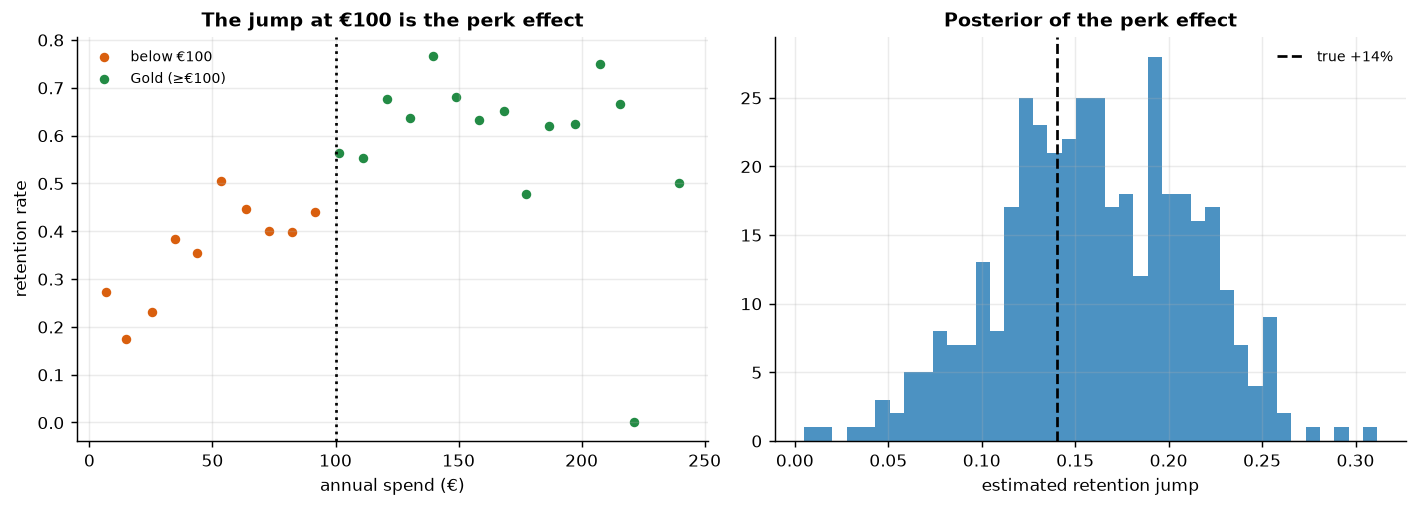

In [4]:
bins = np.linspace(df.spend.min(), min(df.spend.max(), 250), 26)
df["bin"] = pd.cut(df.spend, bins)
binned = df.groupby("bin", observed=True).agg(spend=("spend","mean"), ret=("retention","mean")).dropna()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
below = binned.spend < CUTOFF
ax[0].scatter(binned.spend[below], binned.ret[below], color=plots.ORANGE, s=18, label="below €100")
ax[0].scatter(binned.spend[~below], binned.ret[~below], color=plots.GREEN, s=18, label="Gold (≥€100)")
ax[0].axvline(CUTOFF, color="k", ls=":"); ax[0].set_xlabel("annual spend (€)"); ax[0].set_ylabel("retention rate")
ax[0].set_title("The jump at €100 is the perk effect"); ax[0].legend(frameon=False, fontsize=8)
ax[1].hist(jump, bins=40, color=plots.BLUE, alpha=0.85); ax[1].axvline(true_jump, color="k", ls="--", label=f"true +{true_jump:.0%}")
ax[1].set_xlabel("estimated retention jump"); ax[1].set_title("Posterior of the perk effect"); ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout()

## 6 · Decide, in euros — does the perk earn its cost, and where to set the cutoff?

Value the retention lift: extra retained customers × their annual value, minus the
perk's cost. We evaluate **at the current €100 margin** (that's what RD identifies) and
report P(perk pays).


In [5]:
ANNUAL_VALUE = 200.0      # € value of retaining one marginal customer a year
PERK_COST   = 15.0        # € cost of the Gold perk per member per year
CUSTOMERS_AT_MARGIN = 3000  # customers near the cutoff the decision affects

value_per_member = jump * ANNUAL_VALUE - PERK_COST
total = value_per_member * CUSTOMERS_AT_MARGIN
p_worth = (value_per_member > 0).mean()
print(f"Net value per marginal member  €{value_per_member.mean():.1f}  (retention gain − €{PERK_COST:.0f} perk cost)")
print(f"Total at the margin            €{total.mean():,.0f}  "
      f"[90% €{np.quantile(total,0.05):,.0f}, €{np.quantile(total,0.95):,.0f}]")
print(f"P(perk pays at €100)           {p_worth:.2f}  → " + ("KEEP / consider lowering cutoff" if p_worth>0.9 else "reconsider"))

Net value per marginal member  €17.2  (retention gain − €15 perk cost)
Total at the margin            €51,686  [90% €540, €99,562]
P(perk pays at €100)           0.95  → KEEP / consider lowering cutoff


## 7 · Caveats

- **RD is *local*.** The effect is identified only *at the cutoff* — it's the perk's
  effect on customers near €100, not on your €500 whales. Don't extrapolate the jump to
  everyone.
- **No manipulation.** If customers can game their spend to just clear €100 (or the
  business nudges them), the running variable is manipulated and the design breaks —
  check the density at the cutoff (McCrary) and watch for heaping at round numbers.
- **Bandwidth is a bias–variance trade-off.** Too wide borrows non-comparable units;
  too narrow throws away data. Local-linear within a sensible bandwidth beats a global
  high-order polynomial.
- **Fuzzy RD if the rule isn't sharp.** If crossing €100 only *raises the probability*
  of Gold (grandfathering, overrides), use the fuzzy-RD ratio (jump in Y ÷ jump in
  P(treated)).
